In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns',999)

### Carregando dados

In [3]:
df = pd.read_csv('processed/df_hepa_atlas.csv')

### Mapeamento de valores 

In [5]:
meta_dict = {
    "tp_not": {
        "descricao": "Tipo de notificação",
        "valores": {1: "Individual", 2: "Surto"}
    },
    "id_agravo": {
        "descricao": "Código do agravo (CID-10 da hepatite)",
        "valores": {"B15": "Hepatite A", "B16": "Hepatite B aguda", "B17": "Outras hepatites virais agudas",
                    "B18": "Hepatite viral crônica", "B19": "Hepatite viral não especificada"}
    },
    "dt_notific": {"descricao": "Data da notificação do caso", "valores": None},
    "sem_not": {"descricao": "Semana epidemiológica da notificação", "valores": None},
    "nu_ano": {"descricao": "Ano da notificação", "valores": None},
    "sg_uf_not": {"descricao": "UF onde o caso foi notificado", "valores": {11: "Rondônia", 12: "Acre", 13: "Amazonas", 14: "Roraima", 15: "Pará", 16: "Amapá", 17: "Tocantins", 21: "Maranhão", 22: "Piauí", 23: "Ceará", 24: "Rio Grande do Norte", 25: "Paraíba", 26: "Pernambuco", 27: "Alagoas", 28: "Sergipe", 29: "Bahia", 31: "Minas Gerais", 32: "Espírito Santo", 33: "Rio de Janeiro", 35: "São Paulo", 41: "Paraná", 42: "Santa Catarina", 43: "Rio Grande do Sul", 50: "Mato Grosso do Sul", 51: "Mato Grosso", 52: "Goiás", 53: "Distrito Federal"}},
    "id_municipio": {"descricao": "Código IBGE do município de notificação", "valores": None},
    "id_regiona": {"descricao": "Código da regional de saúde da notificação", "valores": None},
    "nu_idade_n": {"descricao": "Idade do paciente em anos", "valores": None},
    "cs_sexo": {"descricao": "Sexo", "valores": {"M": "Masculino", "F": "Feminino", "I": "Ignorado"}},
    "cs_gestant": {"descricao": "Situação gestacional", "valores": {1: "1º trimestre", 2: "2º trimestre", 3: "3º trimestre", 4: "Idade gestacional ignorada", 5: "Não", 6: "Não se aplica", 9: "Ignorado"}},
    "cs_raca": {"descricao": "Raça/Cor", "valores": {1: "Branca", 2: "Preta", 3: "Amarela", 4: "Parda", 5: "Indígena", 9: "Ignorado"}},
    "cs_escol_n": {"descricao": "Escolaridade", "valores": {0: "Analfabeto", 1: "1ª a 4ª série incompleta", 2: "4ª série completa", 3: "5ª a 8ª série incompleta", 4: "Ensino fundamental completo", 5: "Ensino médio incompleto", 6: "Ensino médio completo", 7: "Superior incompleto", 8: "Superior completo", 9: "Ignorado"}},
    "sg_uf": {"descricao": "UF de residência do paciente", "valores": {11: "Rondônia", 12: "Acre", 13: "Amazonas", 14: "Roraima", 15: "Pará", 16: "Amapá", 17: "Tocantins", 21: "Maranhão", 22: "Piauí", 23: "Ceará", 24: "Rio Grande do Norte", 25: "Paraíba", 26: "Pernambuco", 27: "Alagoas", 28: "Sergipe", 29: "Bahia", 31: "Minas Gerais", 32: "Espírito Santo", 33: "Rio de Janeiro", 35: "São Paulo", 41: "Paraná", 42: "Santa Catarina", 43: "Rio Grande do Sul", 50: "Mato Grosso do Sul", 51: "Mato Grosso", 52: "Goiás", 53: "Distrito Federal"}},
    "id_mn_resi": {"descricao": "Código IBGE do município de residência", "valores": None},
    "id_rg_resi": {"descricao": "Código da regional de residência", "valores": None},
    "id_pais": {"descricao": "Código do país de residência", "valores": None},
    "id_ocupa_n": {"descricao": "Código da ocupação (CBO)", "valores": None},
    "dt_invest": {"descricao": "Data de início da investigação", "valores": None},
    "classi_fin": {"descricao": "Classificação final do caso", "valores": {1: "Confirmado", 2: "Descartado", 3: "Inconclusivo", 4: "Ignorado", 8: "Em investigação"}},
    "dt_encerra": {"descricao": "Data de encerramento da investigação", "valores": None},
    "ano": {"descricao": "Ano do encerramento (derivado de dt_encerra)", "valores": None},
    "dt_diag": {"descricao": "Data do diagnóstico laboratorial", "valores": None},
    "sem_diag": {"descricao": "Semana epidemiológica do diagnóstico", "valores": None},
    "hepatite_n": {"descricao": "Tipo de hepatite", "valores": {1: "A", 2: "B", 3: "C", 4: "D", 5: "E"}},
    "hepatita": {"descricao": "Marcador de hepatite A (IgM anti-HAV positivo)", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 9: "Ignorado"}},
    "hepatitb": {"descricao": "Marcador de hepatite B (HBsAg positivo)", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 9: "Ignorado"}},
    "forma_valida": {"descricao": "Forma clínica da hepatite", "valores": {1: "Aguda", 2: "Crônica/Portador", 99: "Ignorado"}},
    "institucio": {"descricao": "Paciente institucionalizado", "valores": {1: "Sim", 2: "Não", 8: "Não se aplica", 9: "Ignorado"}},
    "hiv": {"descricao": "Co-infecção por HIV", "valores": {1: "Sim", 2: "Não", 9: "Ignorado"}},
    "outra_dst": {"descricao": "Outra DST associada", "valores": {1: "Sim", 2: "Não", 9: "Ignorado"}},
    "sexual": {"descricao": "Comportamento sexual de risco", "valores": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"}},
    "domicili": {"descricao": "Contato domiciliar com portador de hepatite", "valores": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"}},
    "ocupacio": {"descricao": "Exposição ocupacional a sangue/material biológico", "valores": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"}},
    "medicament": {"descricao": "Uso de medicamentos injetáveis não prescritos", "valores": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"}},
    "tatu_pier": {"descricao": "Tatuagem ou piercing", "valores": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"}},
    "matbiologi": {"descricao": "Manipulação de material biológico", "valores": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"}},
    "inal_crack": {"descricao": "Uso de drogas inaladas (crack, cocaína)", "valores": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"}},
    "acupuntura": {"descricao": "Fez acupuntura", "valores": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"}},
    "transfusao": {"descricao": "Recebeu transfusão de sangue", "valores": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"}},
    "injetaveis": {"descricao": "Uso de drogas injetáveis", "valores": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"}},
    "cirurgico": {"descricao": "Procedimentos cirúrgicos prévios", "valores": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"}},
    "agua_alime": {"descricao": "Ingestão de água/alimentos contaminados", "valores": {1: "Sim", 2: "Não", 9: "Ignorado"}},
    "dentario": {"descricao": "Atendimento odontológico recente", "valores": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"}},
    "tresmais": {"descricao": "Mais de 3 parceiros sexuais", "valores": {1: "Sim", 2: "Não", 3: "Não s aplica", 9: "Ignorado"}},
    "hemodialis": {"descricao": "Paciente em hemodiálise", "valores": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"}},
    "transpla": {"descricao": "Paciente transplantado", "valores": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"}},
    "outras": {"descricao": "Outras exposições não listadas", "valores": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"}},
    "dt_acident": {"descricao": "Data de provável exposição/acidente", "valores": None},
    "co_uf_exp": {"descricao": "UF provável de infecção (1ª hipótese)", "valores": None},
    "co_mun_exp": {"descricao": "Município provável de infecção (1ª hipótese)", "valores": None},
    "co_uf_ex2": {"descricao": "UF provável de infecção (2ª hipótese)", "valores": None},
    "co_mun_ex2": {"descricao": "Município provável de infecção (2ª hipótese)", "valores": None},
    "co_uf_ex3": {"descricao": "UF provável de infecção (3ª hipótese)", "valores": None},
    "co_mun_ex3": {"descricao": "Município provável de infecção (3ª hipótese)", "valores": None},
    "bancosangu": {"descricao": "Frequentou/trabalhou em banco de sangue", "valores": {1: "Sim", 2: "Não", 9: "Ignorado"}},
    "res_hbsag": {"descricao": "Resultado do teste HBsAg (hepatite B)", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 4: "Não realizado", 9: "Ignorado"}},
    "re_antihbc": {"descricao": "Resultado do teste Anti-HBc (hepatite B)", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 4: "Não realizado", 9: "Ignorado"}},
    "re_antihcv": {"descricao": "Resultado do teste Anti-HCV (hepatite C)", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 4: "Não realizado", 9: "Ignorado"}},
    "dt_coleta": {"descricao": "Data da coleta da amostra", "valores": None},
    "antihavigm": {"descricao": "Teste Anti-HAV IgM (hepatite A)", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 4: "Não realizado", 9: "Ignorado"}},
    "antihbs": {"descricao": "Teste Anti-HBs (imunidade hepatite B)", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 4: "Não realizado", 9: "Ignorado"}},
    "antihdvigm": {"descricao": "Teste Anti-HDV IgM (hepatite D)", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 4: "Não realizado", 9: "Ignorado"}},
    "aghbs": {"descricao": "Antígeno HBs (hepatite B)", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 4: "Não realizado", 9: "Ignorado"}},
    "aghbe": {"descricao": "Antígeno HBe (hepatite B, replicação viral)", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 4: "Não realizado", 9: "Ignorado"}},
    "antihevigm": {"descricao": "Teste Anti-HEV IgM (hepatite E)", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 4: "Não realizado", 9: "Ignorado"}},
    "antihbcigm": {"descricao": "Teste Anti-HBc IgM (infecção aguda B)", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 4: "Não realizado", 9: "Ignorado"}},
    "antihbe": {"descricao": "Teste Anti-HBe (fase não replicativa B)", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 4: "Não realizado", 9: "Ignorado"}},
    "antihcv": {"descricao": "Teste Anti-HCV (hepatite C)", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 4: "Não realizado", 9: "Ignorado"}},
    "hbc_total": {"descricao": "Anticorpo total Anti-HBc", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 4: "Não realizado", 9: "Ignorado"}},
    "antihdv": {"descricao": "Anticorpo total Anti-HDV", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 4: "Não realizado", 9: "Ignorado"}},
    "tp_sorohcv": {"descricao": "Tipo de sorologia para HCV", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 4: "Não realizado", 9: "Ignorado"}},
    "gen_vhc": {"descricao": "Genótipo do vírus da hepatite C", "valores": {1: "1a", 2: "1b", 3: "2a", 4: "2b", 5: "3a", 6: "3b", 7: "4", 8: "5", 9: "Ignorado"}},
    "coletamarc": {"descricao": "Indicador de coleta de marcadores sorológicos", "valores": None},
    "fonte": {"descricao": "Fonte notificadora", "valores": {1: "UBS", 2: "Hospital", 11: "Laboratório", 99: "Outros/ignorado"}},
    "dsfonte": {"descricao": "Descrição detalhada da fonte notificadora", "valores": None},
    "hav": {"descricao": "Indicador da hepatite A", "valores": {1: "Sim", 0: "Não"}},
    "hbv": {"descricao": "Indicador da hepatite B", "valores": {1: "Sim", 0: "Não"}},
    "hcv": {"descricao": "Indicador da hepatite C", "valores": {1: "Sim", 0: "Não"}},
    "hdv": {"descricao": "Indicador da hepatite D", "valores": {1: "Sim", 0: "Não"}},
    "hev": {"descricao": "Indicador da hepatite E", "valores": {1: "Sim", 0: "Não"}}
}


In [6]:
def aplicar_mapeamentos(df, meta_dict,cols_map):
    """
    Para cada coluna do dataframe que existir no meta_dict e tiver mapeamento,
    cria uma nova coluna com sufixo '_DESC' contendo a descrição dos valores.
    """
    df_mapeado = df.copy()
    
    for col in cols_map:
        if col in df_mapeado.columns and meta_dict[col].get("valores") is not None:
            mapa = meta_dict[col]["valores"]
            
            # Faz o mapeamento dos valores e preserva NaNs
            df_mapeado[col] = df_mapeado[col].map(mapa)
            
    return df_mapeado


In [26]:
columns_map = ['sg_uf_not','id_municipio','nu_idade_n','cs_gestant','sg_uf','id_mn_resi','id_pais','classi_fin','bancosangu','fonte','forma_valida',]
df_EDA=aplicar_mapeamentos(df, meta_dict,columns_map)
df_EDA

,sg_uf_not,id_municipio,nu_idade_n,cs_sexo,cs_gestant,cs_raca,cs_escol_n,sg_uf,id_mn_resi,id_pais,id_ocupa_n,classi_fin,bancosangu,coletamarc,fonte,hav_flag,hbv_flag,hcv_flag,hdv_flag,hev_flag,num_virus,idade_anos,faixa_etaria,cs_raca_limpa,forma_valida,injetaveis_flag,transfusao_flag,hemodialis_flag,transpla_flag,score_risco_alto,vulneravel,decada_idade,antihavigm_desc,antihbs_desc,antihdvigm_desc,aghbs_desc,aghbe_desc,antihevigm_desc,antihbcigm_desc,antihbe_desc,antihcv_desc,hbc_total_desc,antihdv_desc,tp_sorohcv_desc,gen_vhc_desc,coletamarc_desc,ano_notific,mes_notific,dia_notific,semana_notific,dia_semana,nome_dia_semana,trimestre,is_fim_semana,is_inicio_ano,is_meio_ano,is_final_ano,mes_sen,mes_cos,dia_sen,dia_cos,is_feriado,expectativa_vida,fecundidade_total,prob_sobrevivencia_40,prob_sobrevivencia_60,taxa_freq_bruta_basico,taxa_freq_bruta_fundamental,taxa_freq_bruta_medio,taxa_freq_liquida_superior,prop_pobreza_extrema,prop_vulner_pobreza,taxa_agua_encanada,taxa_banheiro_agua_encanada,taxa_coleta_lixo,taxa_energia_eletrica,taxa_agua_esgoto_inadequados,taxa_paredes_inadequados,populacao,indice_escolaridade,indice_frequencia_escolar,idhm,idhm_e,idhm_l,idhm_r
0,Goiás,520870,4044,Masculino,Não se aplica,Branca,Superior Incompleto,Goiás,522045.0,1,Porteiro industrial,Ignorado,Não,20140312,Outros/ignorado,0,0,1,0,0,1,44,31-50 anos,1.0,NaN,0,0,0,0,0,0,40,Não realizado,Não realizado,Não realizado,Negativo,Não realizado,Não realizado,Negativo,Não realizado,Positivo,Negativo,Não realizado,Negativo,NaN,Não realizado,2015,1,1,1,3,Quinta-feira,1,False,True,False,False,5.000000e-01,0.866025,2.012985e-01,0.97953,False,75.28,1.42,93.84,83.88,98.52,104.86,81.99,27.94,0.54,12.70,99.49,95.44,99.92,99.96,1.56,0.16,1302001,0.714,0.752,0.799,0.739,0.838,0.824
1,Tocantins,170210,4020,Feminino,2º trimestre,Parda,Médio Completo,Tocantins,170210.0,1,Nao informado,Confirmado,NaN,20141027,UBS,0,1,0,0,0,1,20,19-30 anos,4.0,Crônica/Portador,0,0,0,0,0,1,20,Negativo,Negativo,Não realizado,Positivo,Negativo,Negativo,Negativo,Positivo,Negativo,Positivo,Não realizado,Não realizado,Não realizado,Não realizado,2015,1,1,1,3,Quinta-feira,1,False,True,False,False,5.000000e-01,0.866025,2.012985e-01,0.97953,False,74.23,1.93,96.15,88.08,102.11,110.37,79.90,23.61,2.91,30.60,97.76,91.60,95.22,98.97,4.45,3.13,150484,0.639,0.751,0.752,0.712,0.821,0.727
2,Rio de Janeiro,330455,4023,Masculino,Não se aplica,Parda,Ignorado,Rio de Janeiro,330455.0,1,Nao informado,Confirmado,NaN,20141208,NaN,1,0,0,0,0,1,23,19-30 anos,4.0,Aguda,0,0,0,0,0,1,20,Positivo,Positivo,Não realizado,Negativo,Não realizado,Não realizado,Negativo,Não realizado,Negativo,Negativo,Não realizado,Não realizado,Não realizado,Não realizado,2015,1,1,1,3,Quinta-feira,1,False,True,False,False,5.000000e-01,0.866025,2.012985e-01,0.97953,False,75.69,1.56,92.95,83.10,106.10,114.16,83.20,20.30,1.25,16.41,99.02,97.39,99.17,99.97,0.30,0.52,6320446,0.722,0.717,0.799,0.719,0.845,0.840
3,Amapá,160030,4032,Feminino,NaN,Preta,NaN,Amapá,160030.0,1,Nao informado,Confirmado,NaN,20141226,Laboratório,1,0,0,0,0,1,32,31-50 anos,2.0,Aguda,0,0,0,0,0,1,30,Positivo,Não realizado,Não realizado,Não realizado,Não realizado,Não realizado,Negativo,Não realizado,Não realizado,Negativo,Não realizado,Não realizado,Não realizado,Não realizado,2015,1,1,1,3,Quinta-feira,1,False,True,False,False,5.000000e-01,0.866025,2.012985e-01,0.97953,False,74.19,2.25,96.64,88.66,98.89,105.84,78.24,16.89,5.89,37.48,95.07,74.07,98.31,99.81,16.25,3.38,398204,0.679,0.655,0.733,0.663,0.820,0.723
4,Acre,120040,4055,Masculino,Não se aplica,Parda,Sem info,Acre,120043.0,1,Volante na agricultura,Confirmado,NaN,20150101,Outros/ignorado,0,0,1,0,0,1,55,51-65 anos,4.0,Crônica/Portador,0,0,0,0,0,1,50,Não realizado,Negativo,Não realizado,Negativo,Não realizado,Não realizado,Não realizado,Não realizado,Positivo,Negativo,Não realizado,Positivo,Positivo,Não realizado,2015,1,1,1,3,Quinta-feira,1,False,True,False,False,5.000000e-01,0.866025,2.012985e-01,0.97953,False,72.85,2.06,

### Resumo dataframe

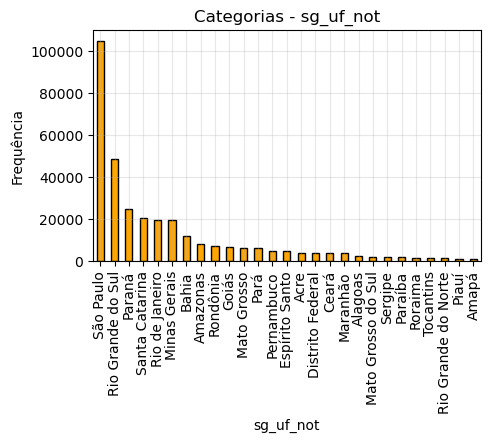

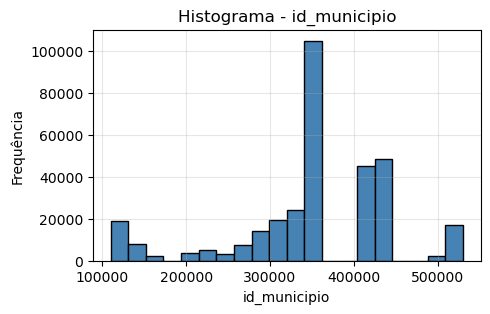

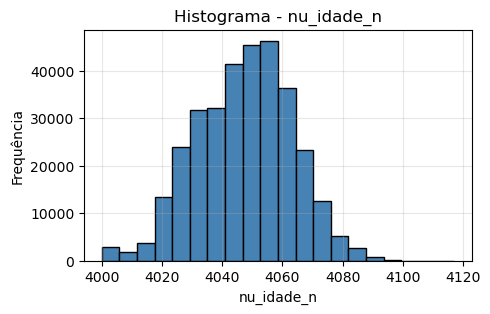

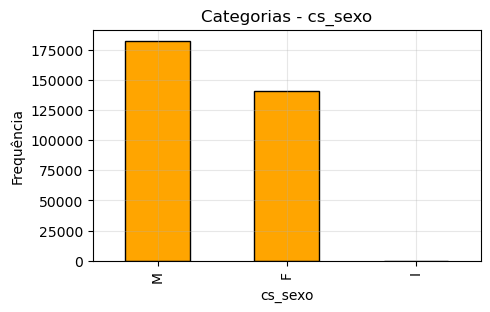

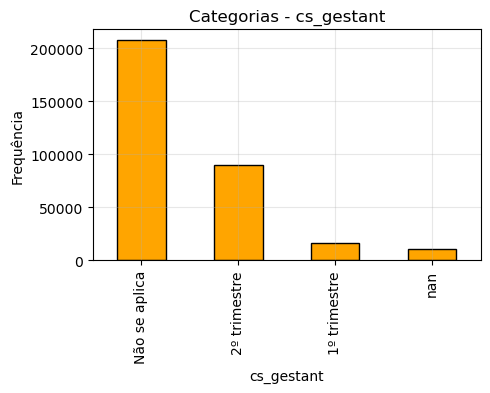

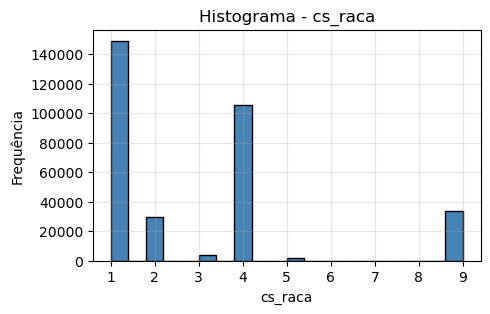

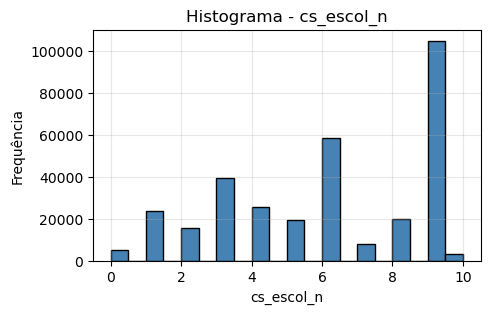

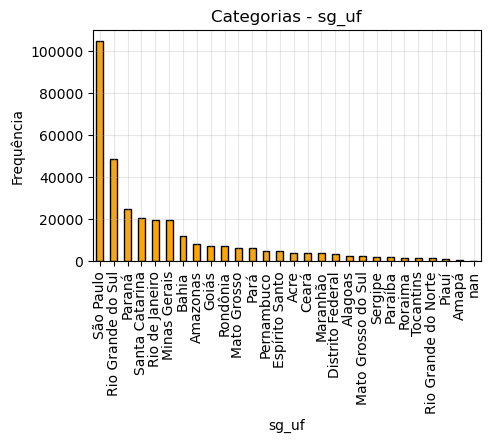

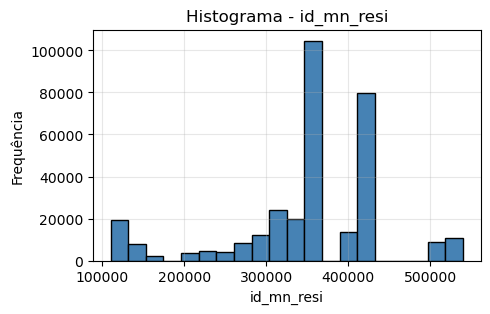

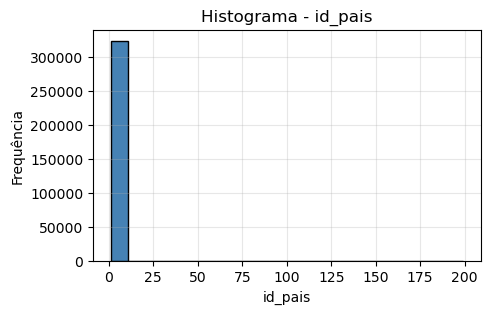

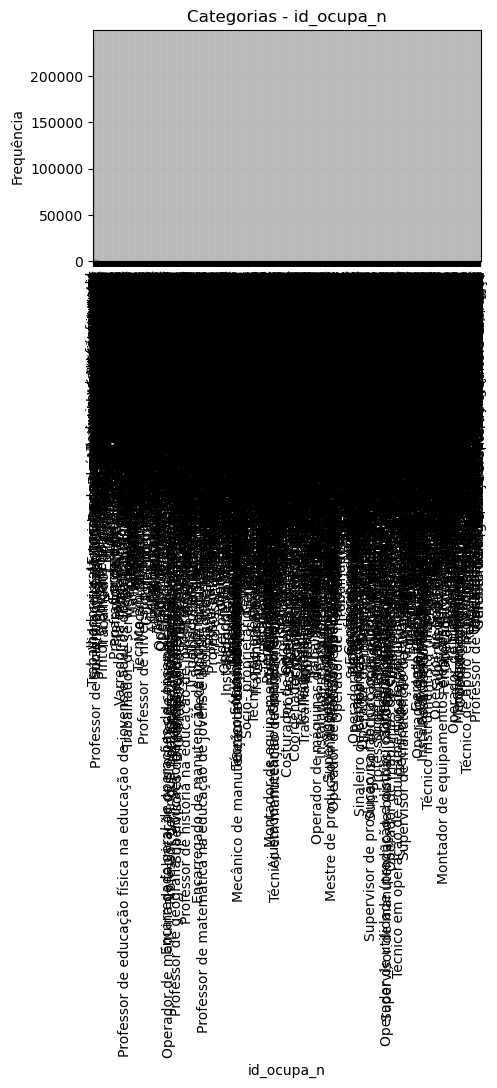

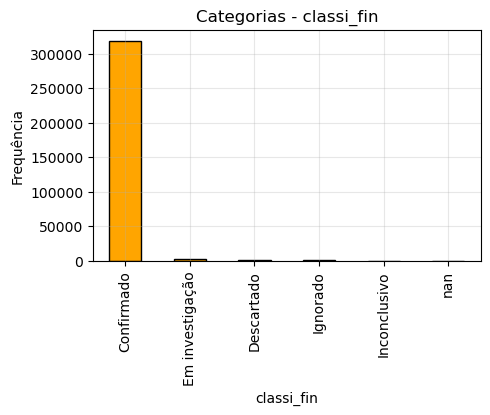

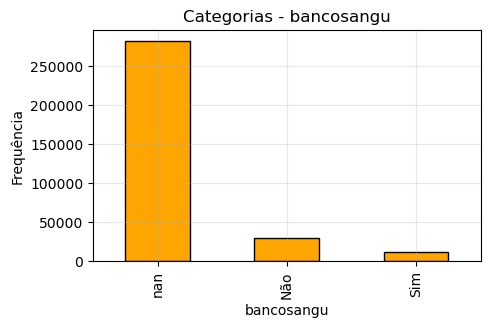

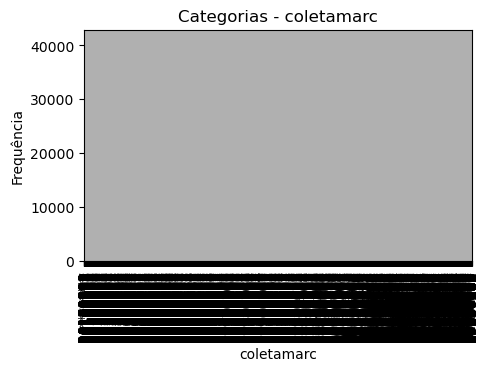

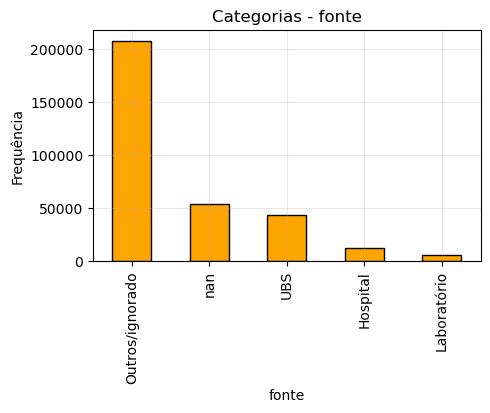

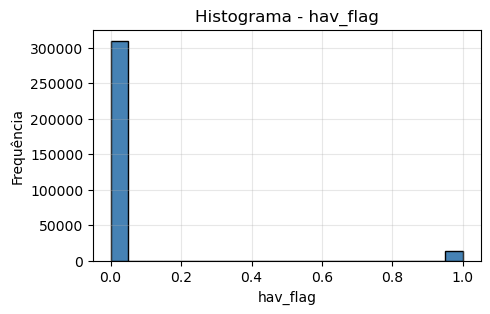

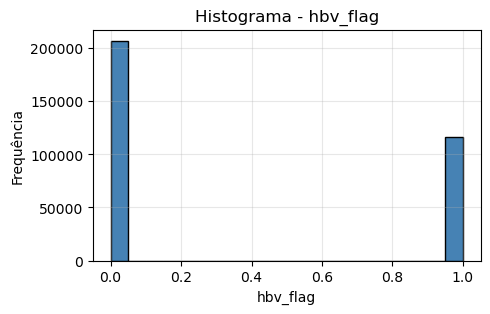

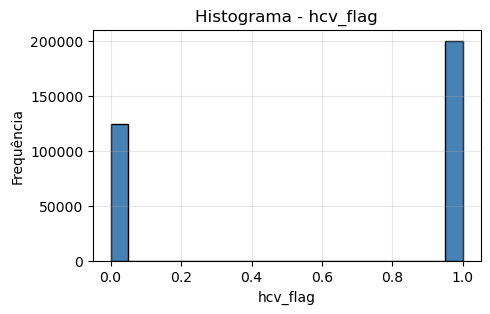

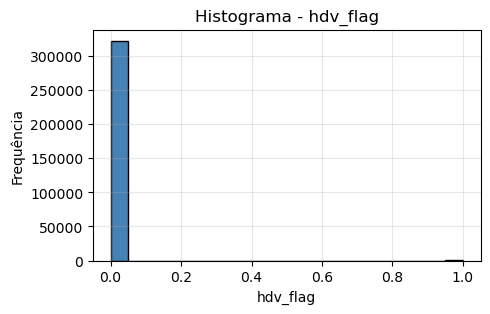

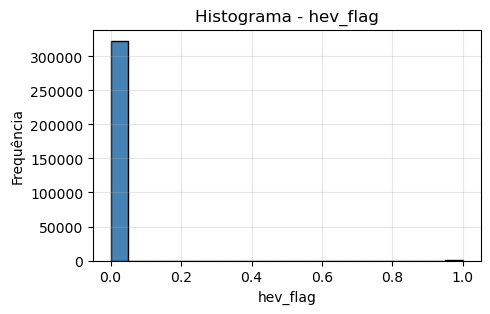

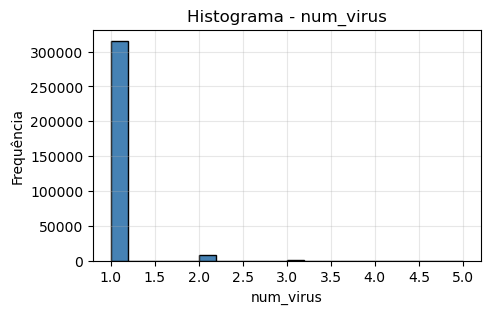

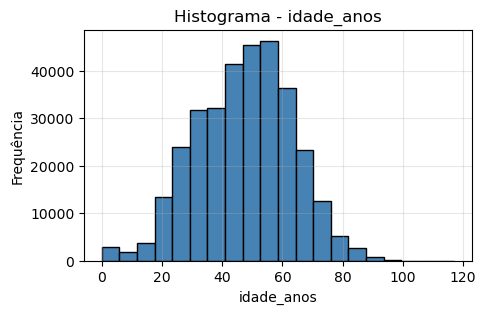

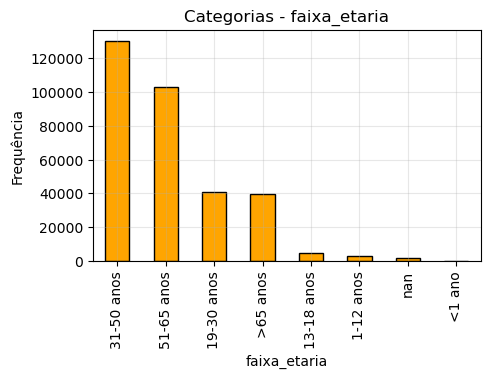

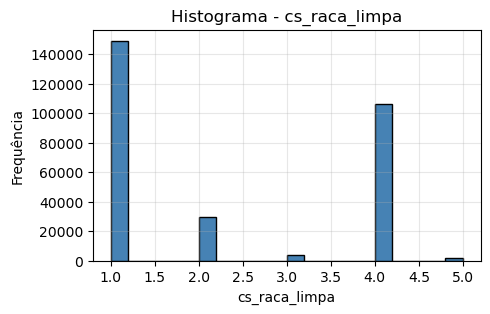

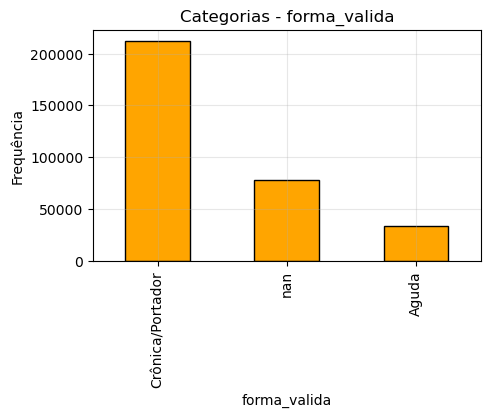

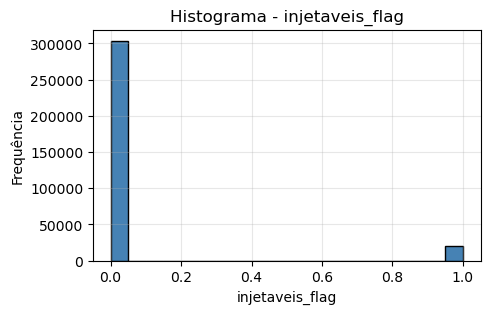

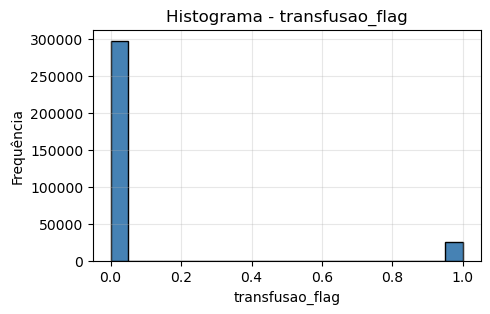

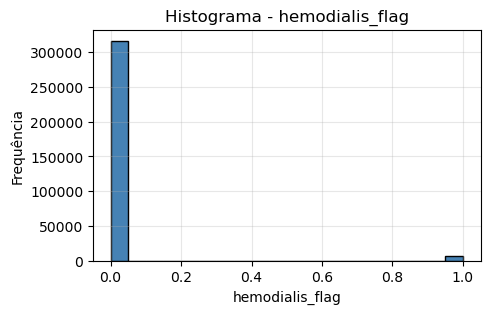

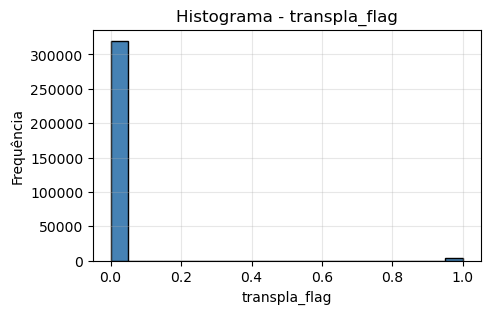

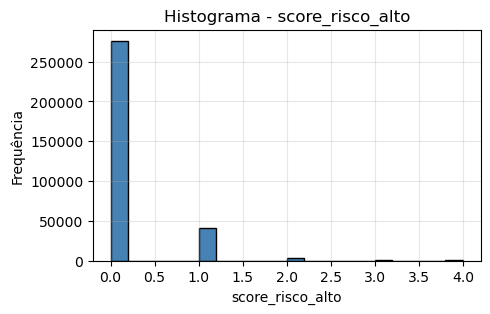

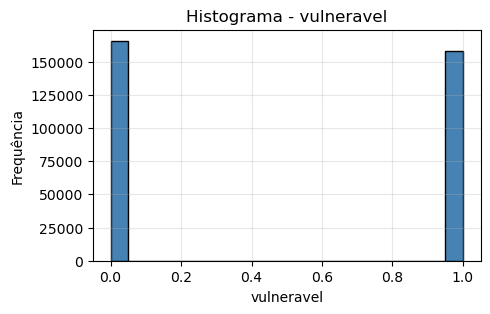

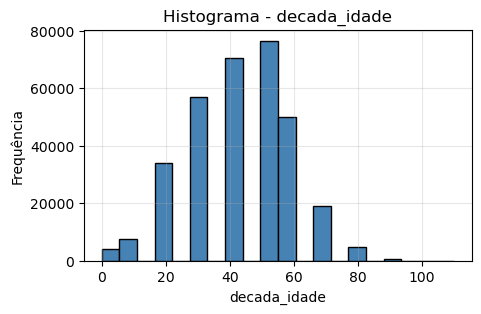

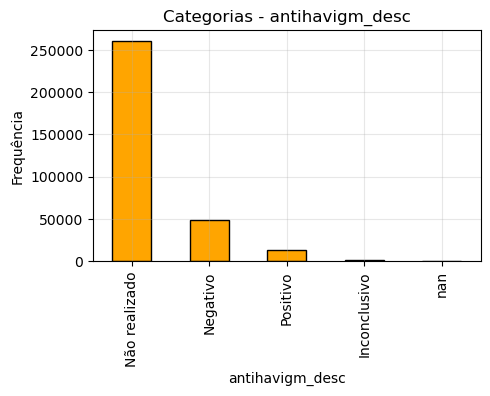

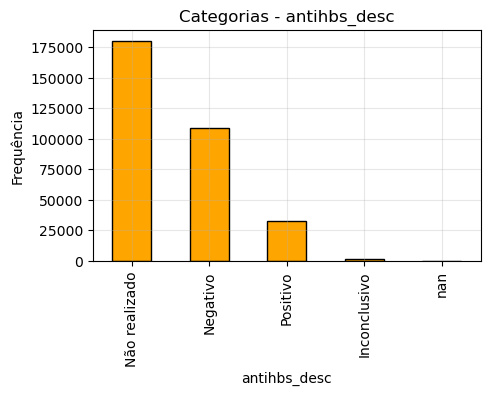

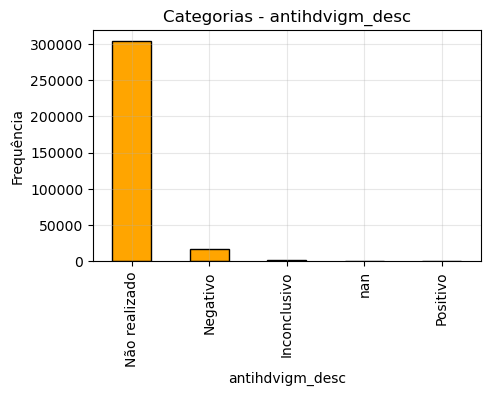

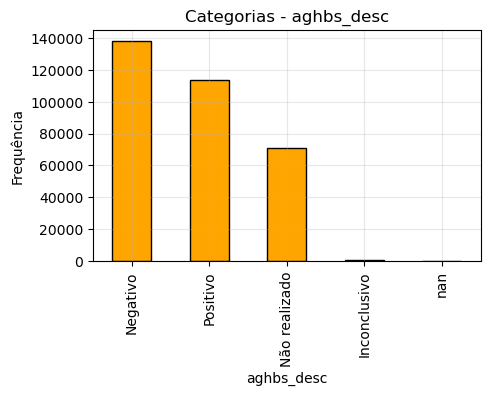

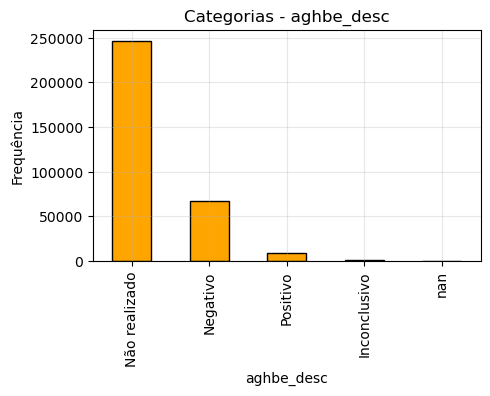

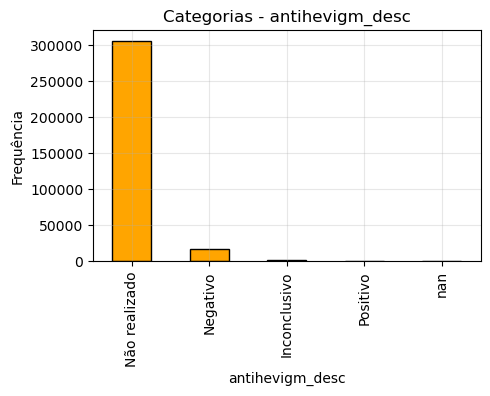

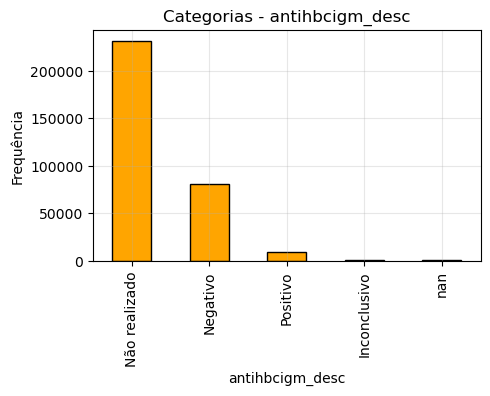

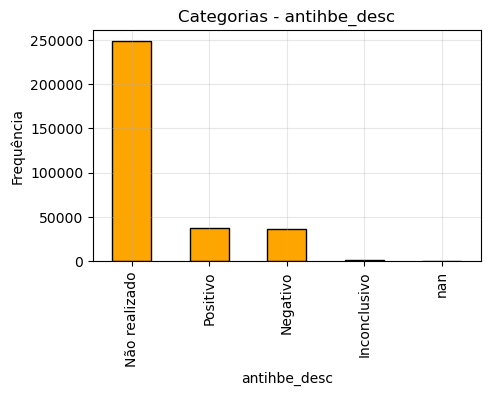

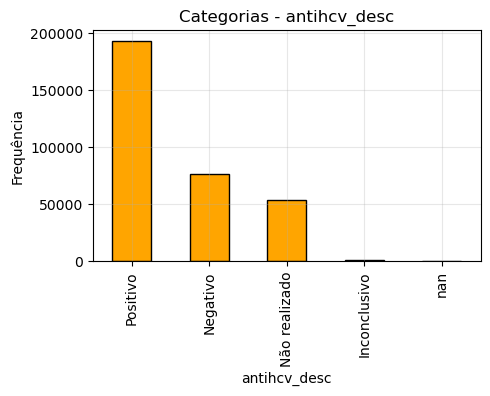

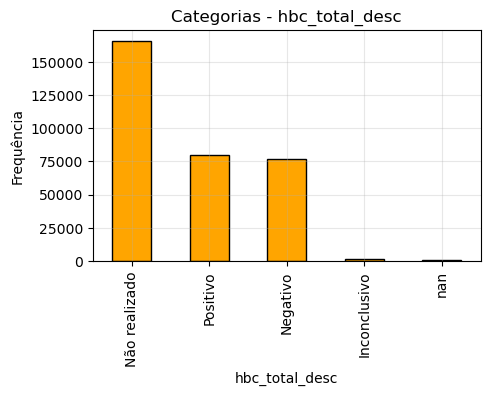

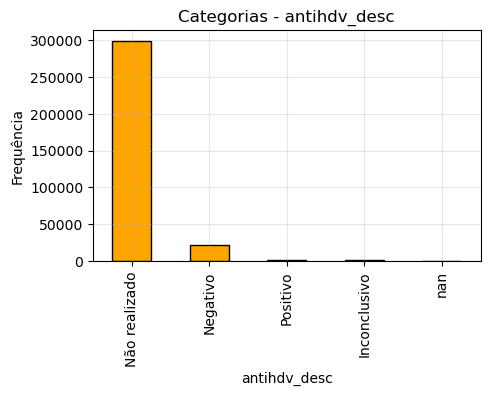

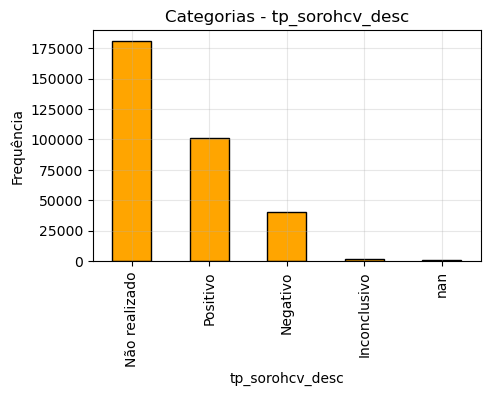

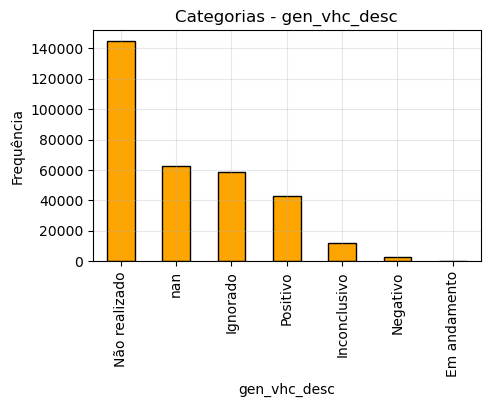

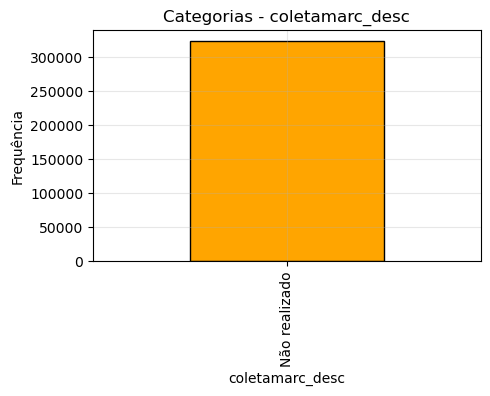

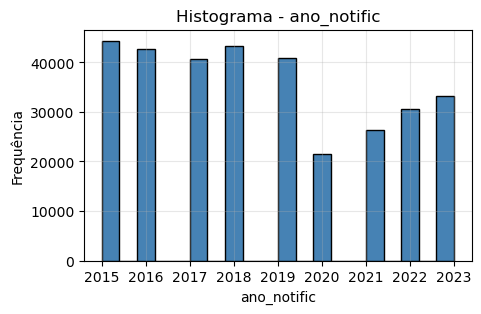

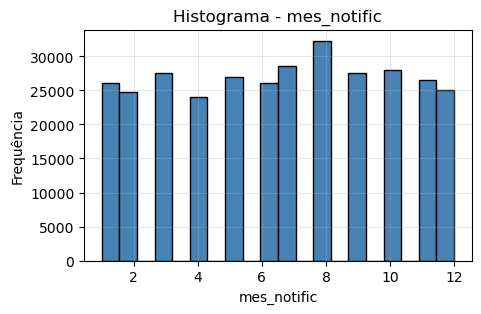

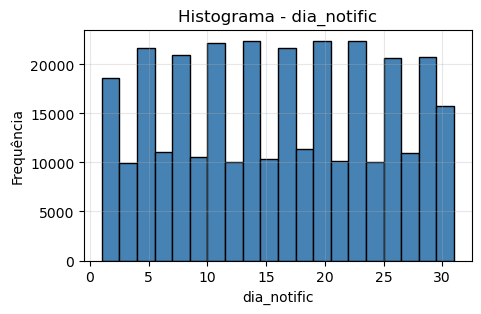

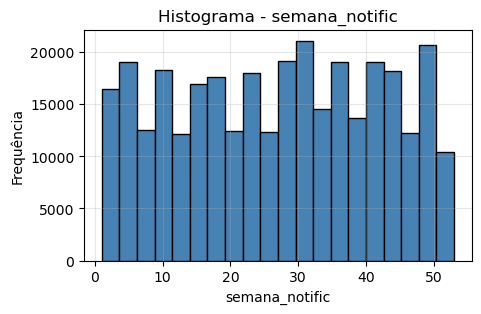

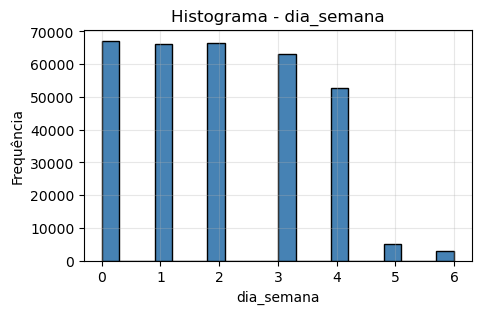

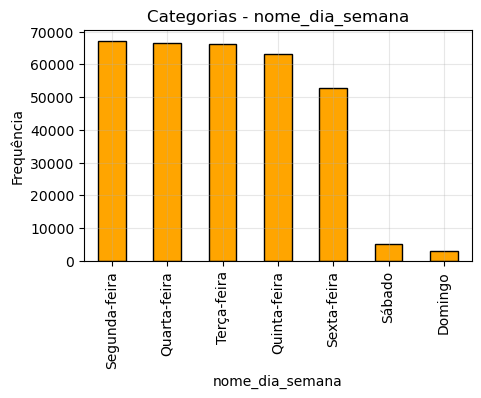

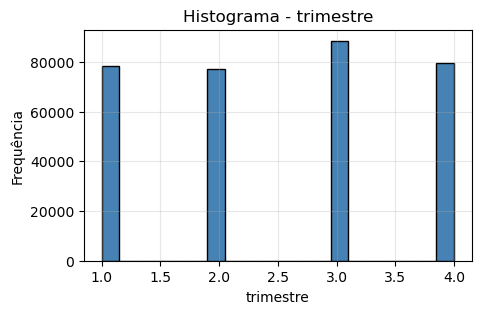

KeyError: 'mean'

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def resumo_dataframe(df):
    resumo = {}
    
    for col in df.columns:
        serie = df[col]
        if col=='ID_OCUPA_N':
            contagem = (
            df['ID_OCUPA_N']
            .dropna()
            .astype(str)
            .value_counts()
            .head(20)
            .reset_index()
            )
            contagem.columns = ["codigo", "frequencia"]
            
            contagem.drop(index=0,inplace=True)
            # Plot
            plt.figure(figsize=(10, 6))
            plt.barh(contagem["codigo"], contagem["frequencia"], color="steelblue", edgecolor="black")
            plt.gca().invert_yaxis()  # o maior aparece no topo
            plt.title(f"Top ocupações mais frequentes", fontsize=14, weight='bold')
            plt.xlabel("Frequência")
            plt.ylabel("Ocupação")
            plt.grid(axis="x", alpha=0.3)
            plt.tight_layout()
            plt.show()       
        elif pd.api.types.is_numeric_dtype(serie):
            desc = serie.describe(percentiles=[0.25, 0.5, 0.75])
            resumo[col] = {
                'tipo': 'numérica',
                'n': desc['count'],
                'média': desc['mean'],
                'mediana': desc['50%'],
                'mínimo': desc['min'],
                'máximo': desc['max'],
                'desvio_padrão': desc['std']
            }
            
            # Plotar histograma
            plt.figure(figsize=(5,3))
            serie.plot(kind='hist', bins=20, color='steelblue', edgecolor='black')
            plt.title(f'Histograma - {col}')
            plt.xlabel(col)
            plt.ylabel('Frequência')
            plt.grid(alpha=0.3)
            plt.show()

        else:
            counts = serie.value_counts(dropna=False)
            resumo[col] = {
                'tipo': 'categórica',
                'n_categorias': len(counts),
                'categorias': counts.to_dict()
            }
            
            # Plotar barras das categorias
            plt.figure(figsize=(5,3))
            counts.plot(kind='bar', color='orange', edgecolor='black')
            plt.title(f'Categorias - {col}')
            plt.ylabel('Frequência')
            plt.grid(alpha=0.3)
            plt.show()
    
    # Retorna resumo geral como DataFrame
    resumo_df = pd.DataFrame(resumo).T
    return resumo_df

resumo_dataframe(df_EDA)

### Análises bivariadas

In [32]:
df_EDA.reset_index(inplace=True)
df_mun = df_EDA.groupby('id_municipio').agg({
          'idhm': 'first',
          'populacao': 'first',
          'taxa_agua_esgoto_inadequados': 'first',
          'taxa_paredes_inadequados': 'first',
          'idhm_r': 'first',
          'expectativa_vida':'first', 
      'fecundidade_total':'first',
      'prob_sobrevivencia_40':'first', 
      'prob_sobrevivencia_60':'first',
      'taxa_freq_bruta_basico':'first',
      'taxa_freq_bruta_fundamental':'first',
      'taxa_freq_bruta_medio':'first',
      'taxa_freq_liquida_superior':'first',
      'prop_pobreza_extrema':'first',
      'prop_vulner_pobreza':'first',
      'taxa_agua_encanada':'first',
      'taxa_banheiro_agua_encanada':'first',
      'taxa_coleta_lixo':'first',
      'taxa_energia_eletrica':'first',
      'taxa_agua_esgoto_inadequados':'first',
      'taxa_paredes_inadequados':'first',
      'populacao':'first',
      'indice_escolaridade':'first',
      'indice_frequencia_escolar':'first',
      'idhm':'first',
      'idhm_e':'first',
      'idhm_l':'first',
      'idhm_r':'first',
      'index': 'count'
      }).rename(columns={'index': 'num_casos'}).reset_index()

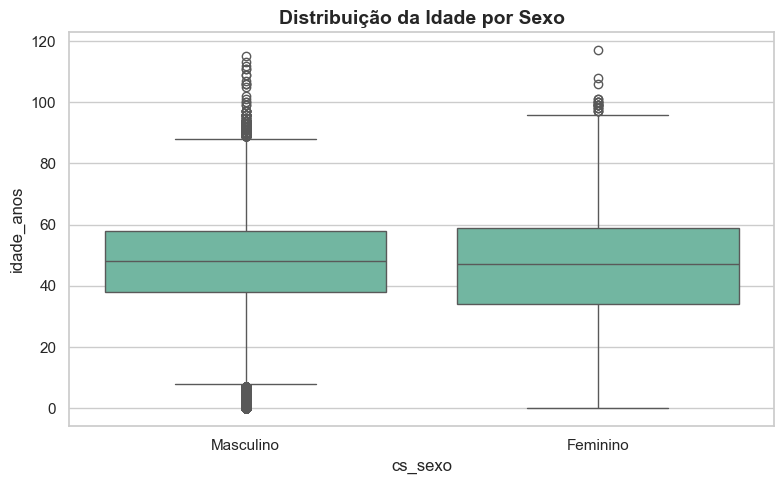

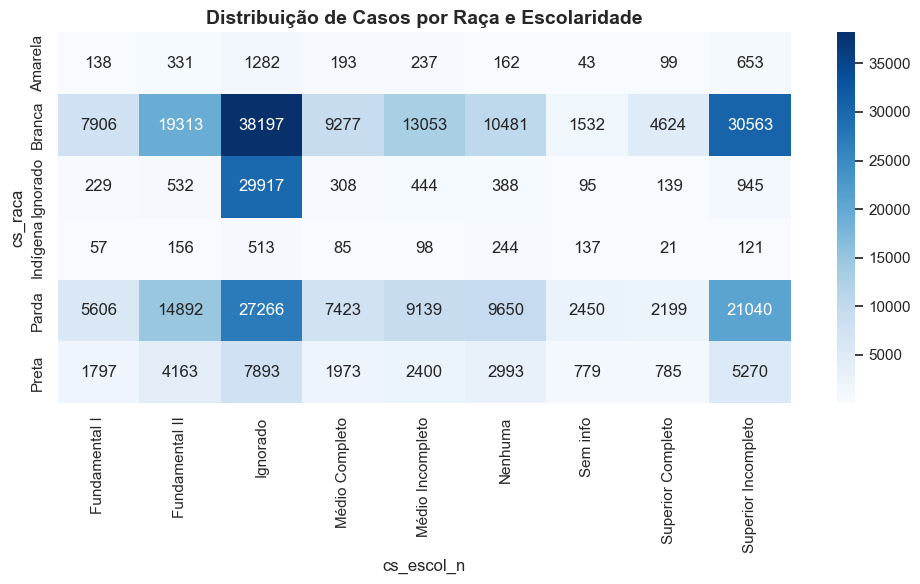

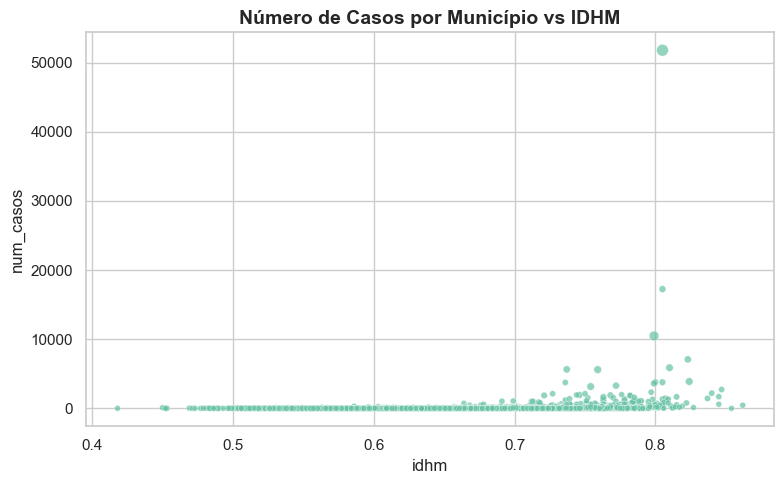

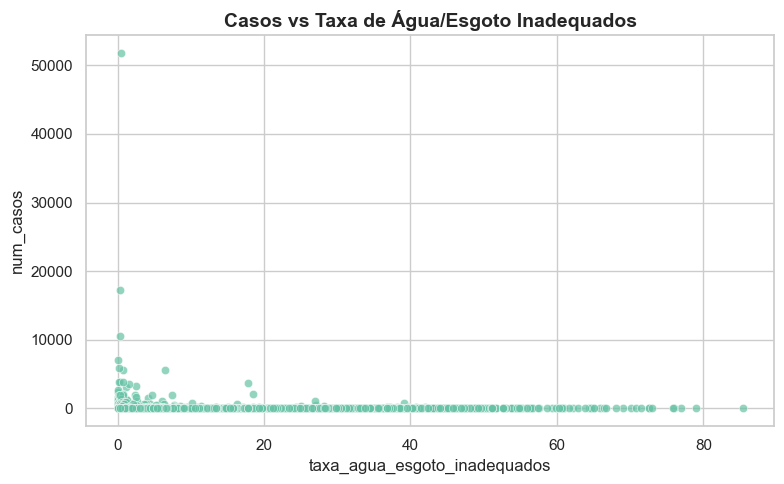

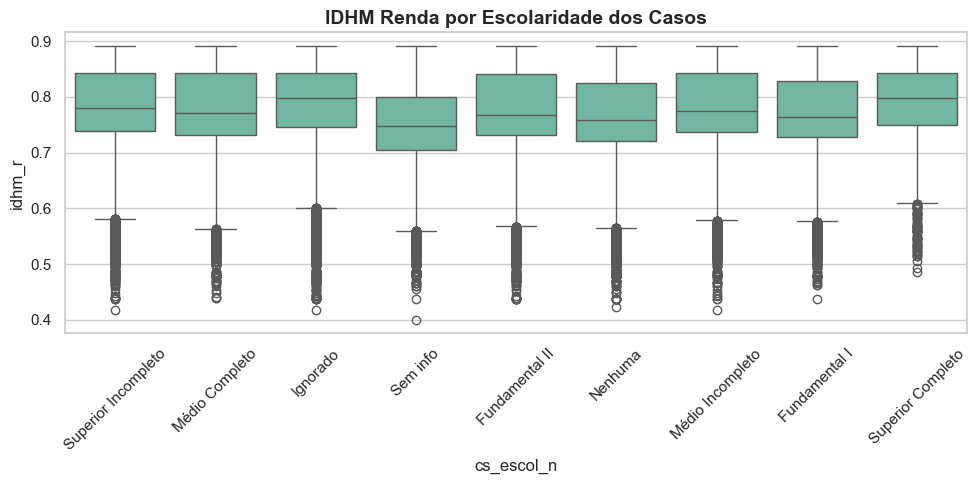

In [35]:


# ------------------------------------------------------------
# 4️⃣ Estilo global dos gráficos
# ------------------------------------------------------------
sns.set(style="whitegrid", palette="Set2")

def show_plot(title):
    """Função auxiliar para formatar e exibir plots."""
    plt.title(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 5️⃣ Gráfico 1 – Boxplot: Idade por sexo
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.boxplot(x='cs_sexo', y='idade_anos', data=df)
show_plot('Distribuição da Idade por Sexo')

# ------------------------------------------------------------
# 6️⃣ Gráfico 2 – Heatmap: Raça × Escolaridade
# ------------------------------------------------------------
pivot = df.pivot_table(index='cs_raca', columns='cs_escol_n', aggfunc='size', fill_value=0)
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt="d", cmap="Blues")
show_plot('Distribuição de Casos por Raça e Escolaridade')

# ------------------------------------------------------------
# 7️⃣ Gráfico 3 – Dispersão: IDHM × Número de Casos
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_mun, x='idhm', y='num_casos', size='populacao', alpha=0.7, legend=False)
show_plot('Número de Casos por Município vs IDHM')

# ------------------------------------------------------------
# 8️⃣ Gráfico 4 – Dispersão: Água/Esgoto Inadequados × Casos
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_mun, x='taxa_agua_esgoto_inadequados', y='num_casos', alpha=0.7)
show_plot('Casos vs Taxa de Água/Esgoto Inadequados')

# ------------------------------------------------------------
# 9️⃣ Gráfico 5 – Boxplot: IDHM Renda × Escolaridade
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.boxplot(x='cs_escol_n', y='idhm_r', data=df)
plt.xticks(rotation=45)
show_plot('IDHM Renda por Escolaridade dos Casos')



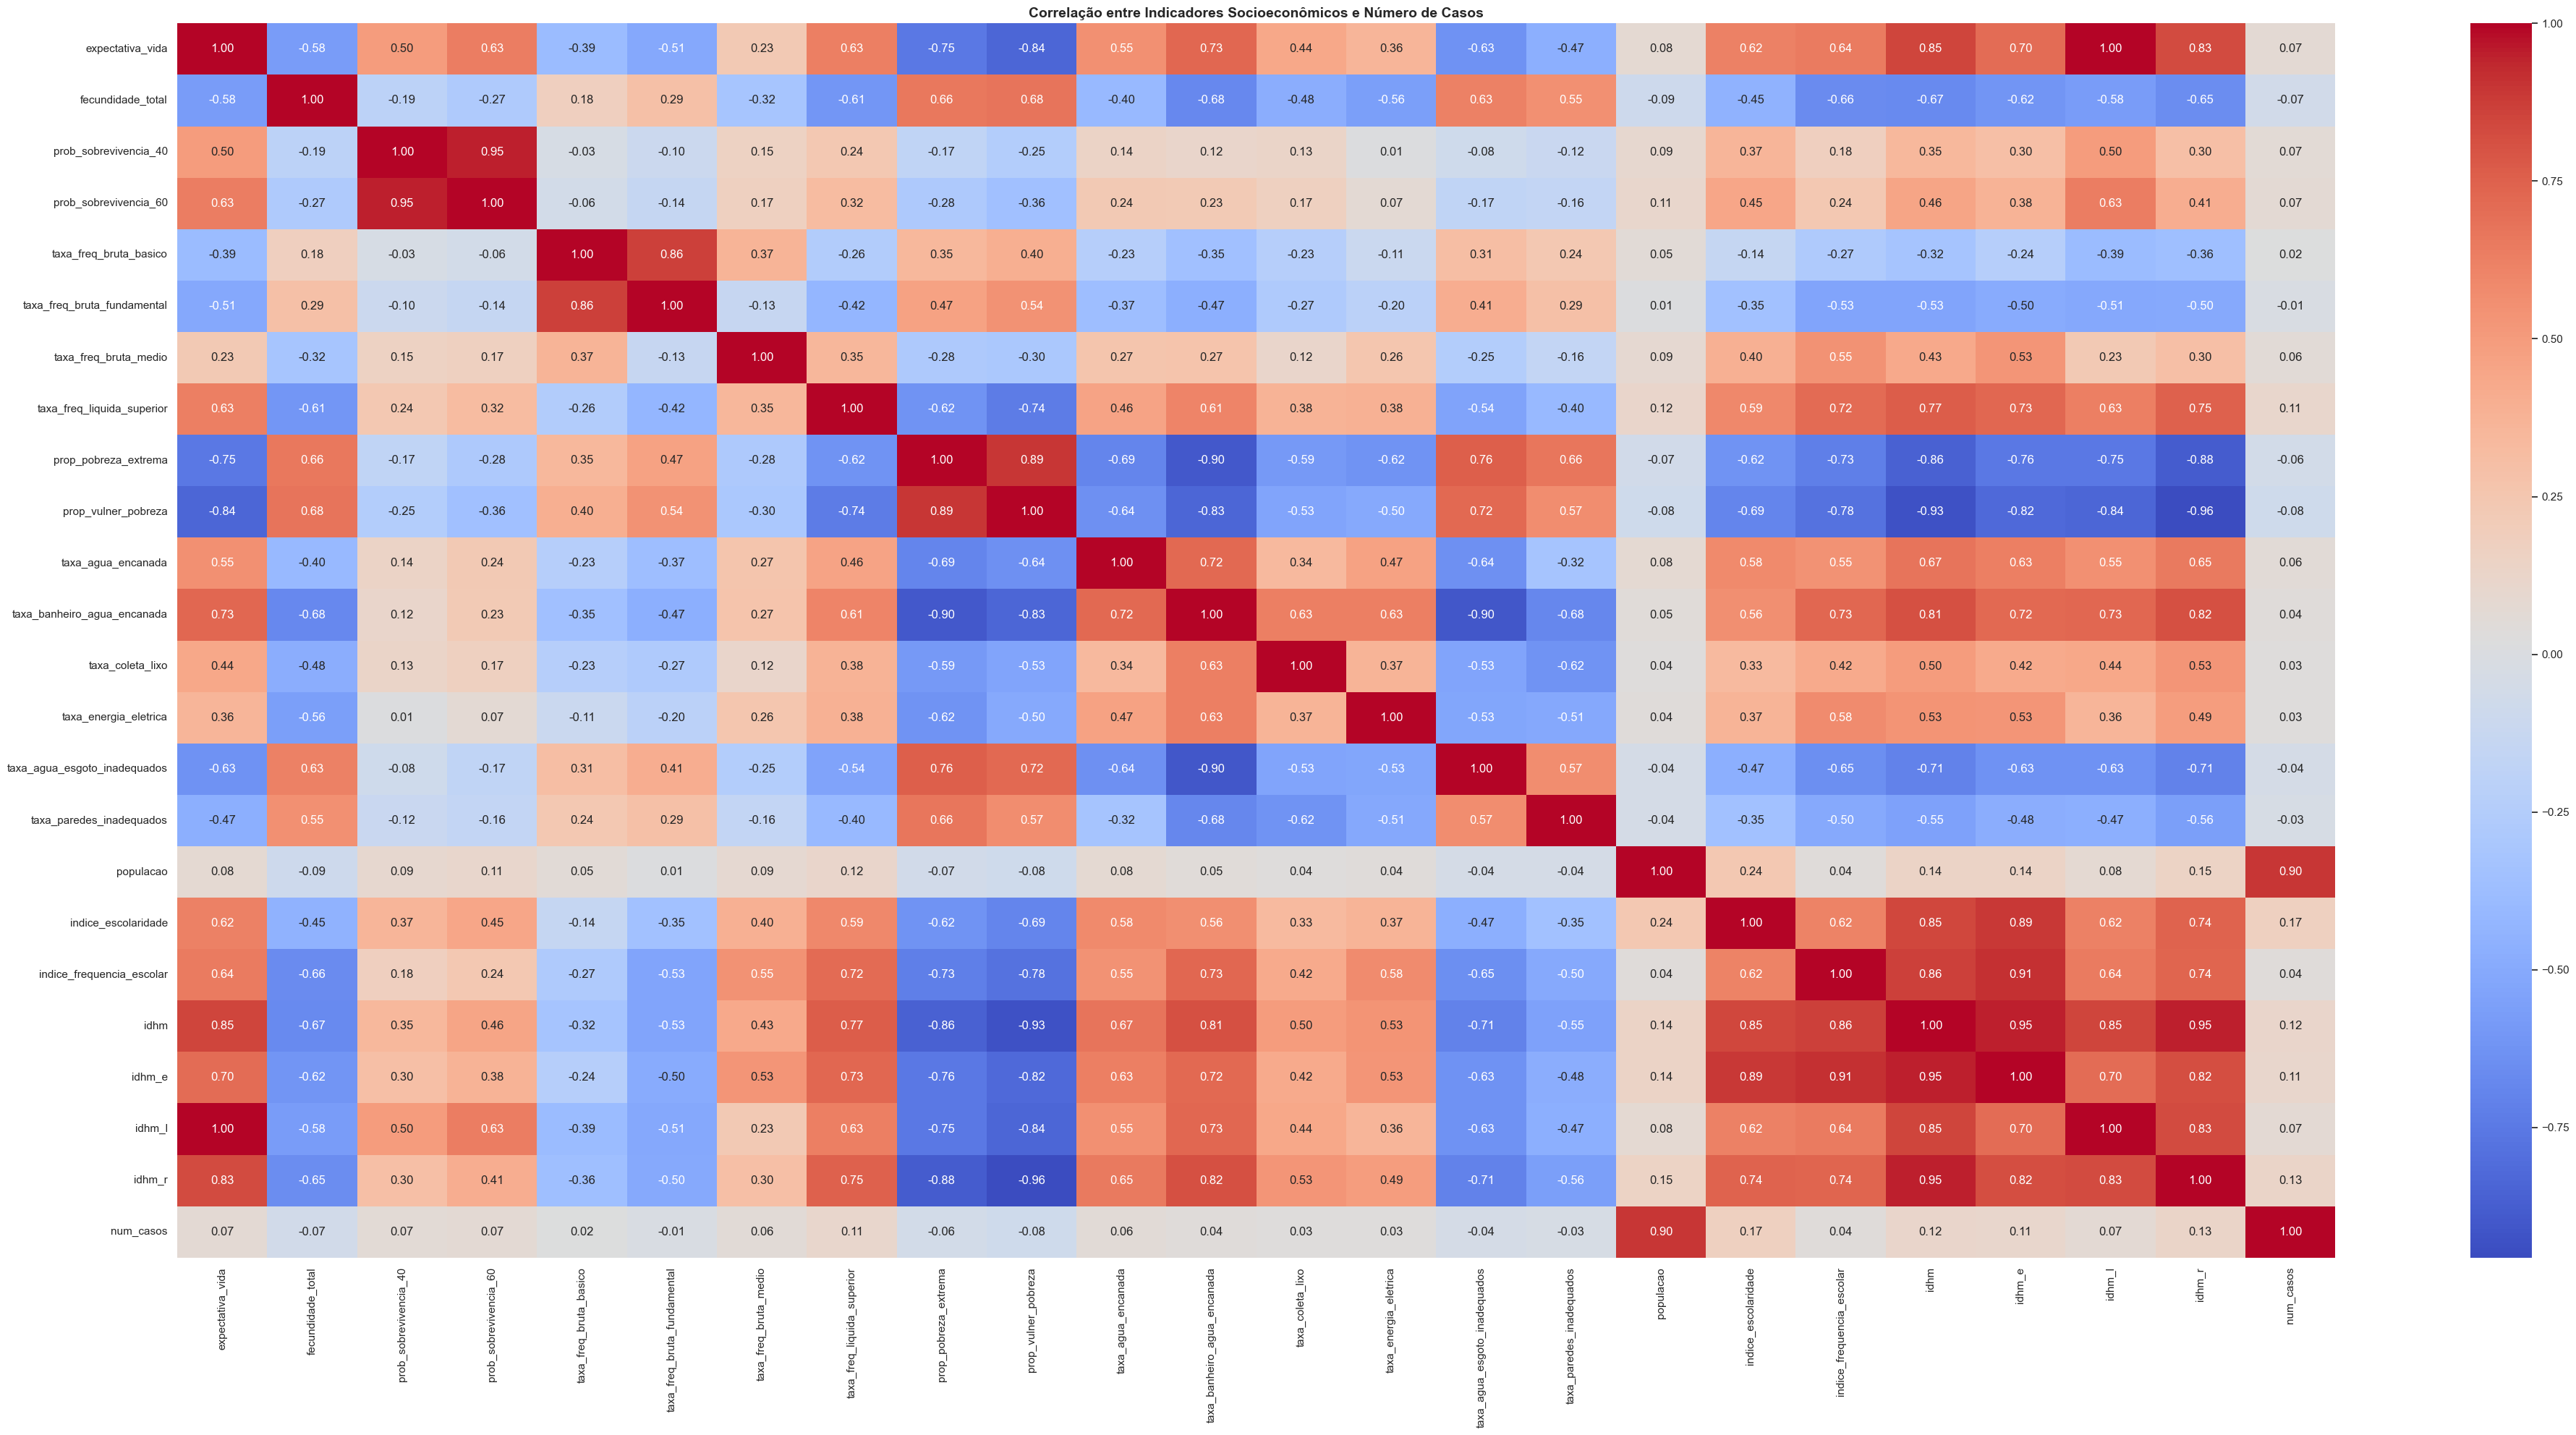

In [39]:
# ------------------------------------------------------------
# 🔟 Gráfico 6 – Heatmap: Correlação entre Indicadores
# ------------------------------------------------------------
atlas_cols = [
'expectativa_vida', 'fecundidade_total',
       'prob_sobrevivencia_40', 'prob_sobrevivencia_60',
       'taxa_freq_bruta_basico', 'taxa_freq_bruta_fundamental',
       'taxa_freq_bruta_medio', 'taxa_freq_liquida_superior',
       'prop_pobreza_extrema', 'prop_vulner_pobreza', 'taxa_agua_encanada',
       'taxa_banheiro_agua_encanada', 'taxa_coleta_lixo',
       'taxa_energia_eletrica', 'taxa_agua_esgoto_inadequados',
       'taxa_paredes_inadequados', 'populacao', 'indice_escolaridade',
       'indice_frequencia_escolar', 'idhm', 'idhm_e', 'idhm_l', 'idhm_r','num_casos'
]
plt.figure(figsize=(40, 20))
sns.heatmap(df_mun[atlas_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
show_plot('Correlação entre Indicadores Socioeconômicos e Número de Casos')


#### Numero de casos por periodo do ano

<Axes: xlabel='periodo_ano', ylabel='num_casos'>

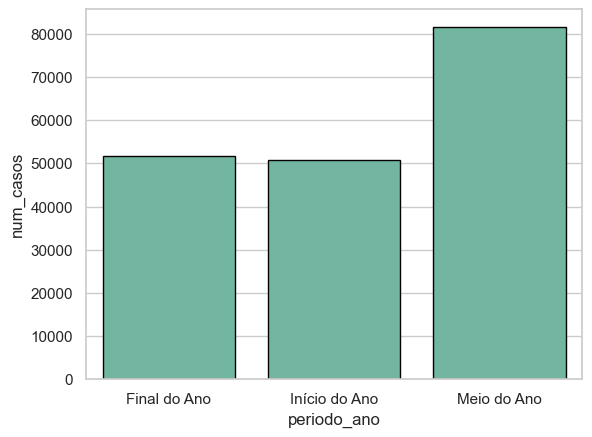

In [40]:

# Contar o número de casos por município e período
df_periodo = pd.DataFrame(df[['is_inicio_ano', 'is_meio_ano', 'is_final_ano']].sum()).reset_index()
df_periodo.columns=['periodo_ano','num_casos']

# Mapear nomes mais legíveis
df_periodo['periodo_ano'] = df_periodo['periodo_ano'].replace({
    'is_inicio_ano': 'Início do Ano',
    'is_meio_ano': 'Meio do Ano',
    'is_final_ano': 'Final do Ano'
})

sns.barplot(
    x='periodo_ano', 
    y='num_casos', 
    data=df_periodo.groupby('periodo_ano').sum().reset_index(), 
    edgecolor='black'
)

### Graficos de exames

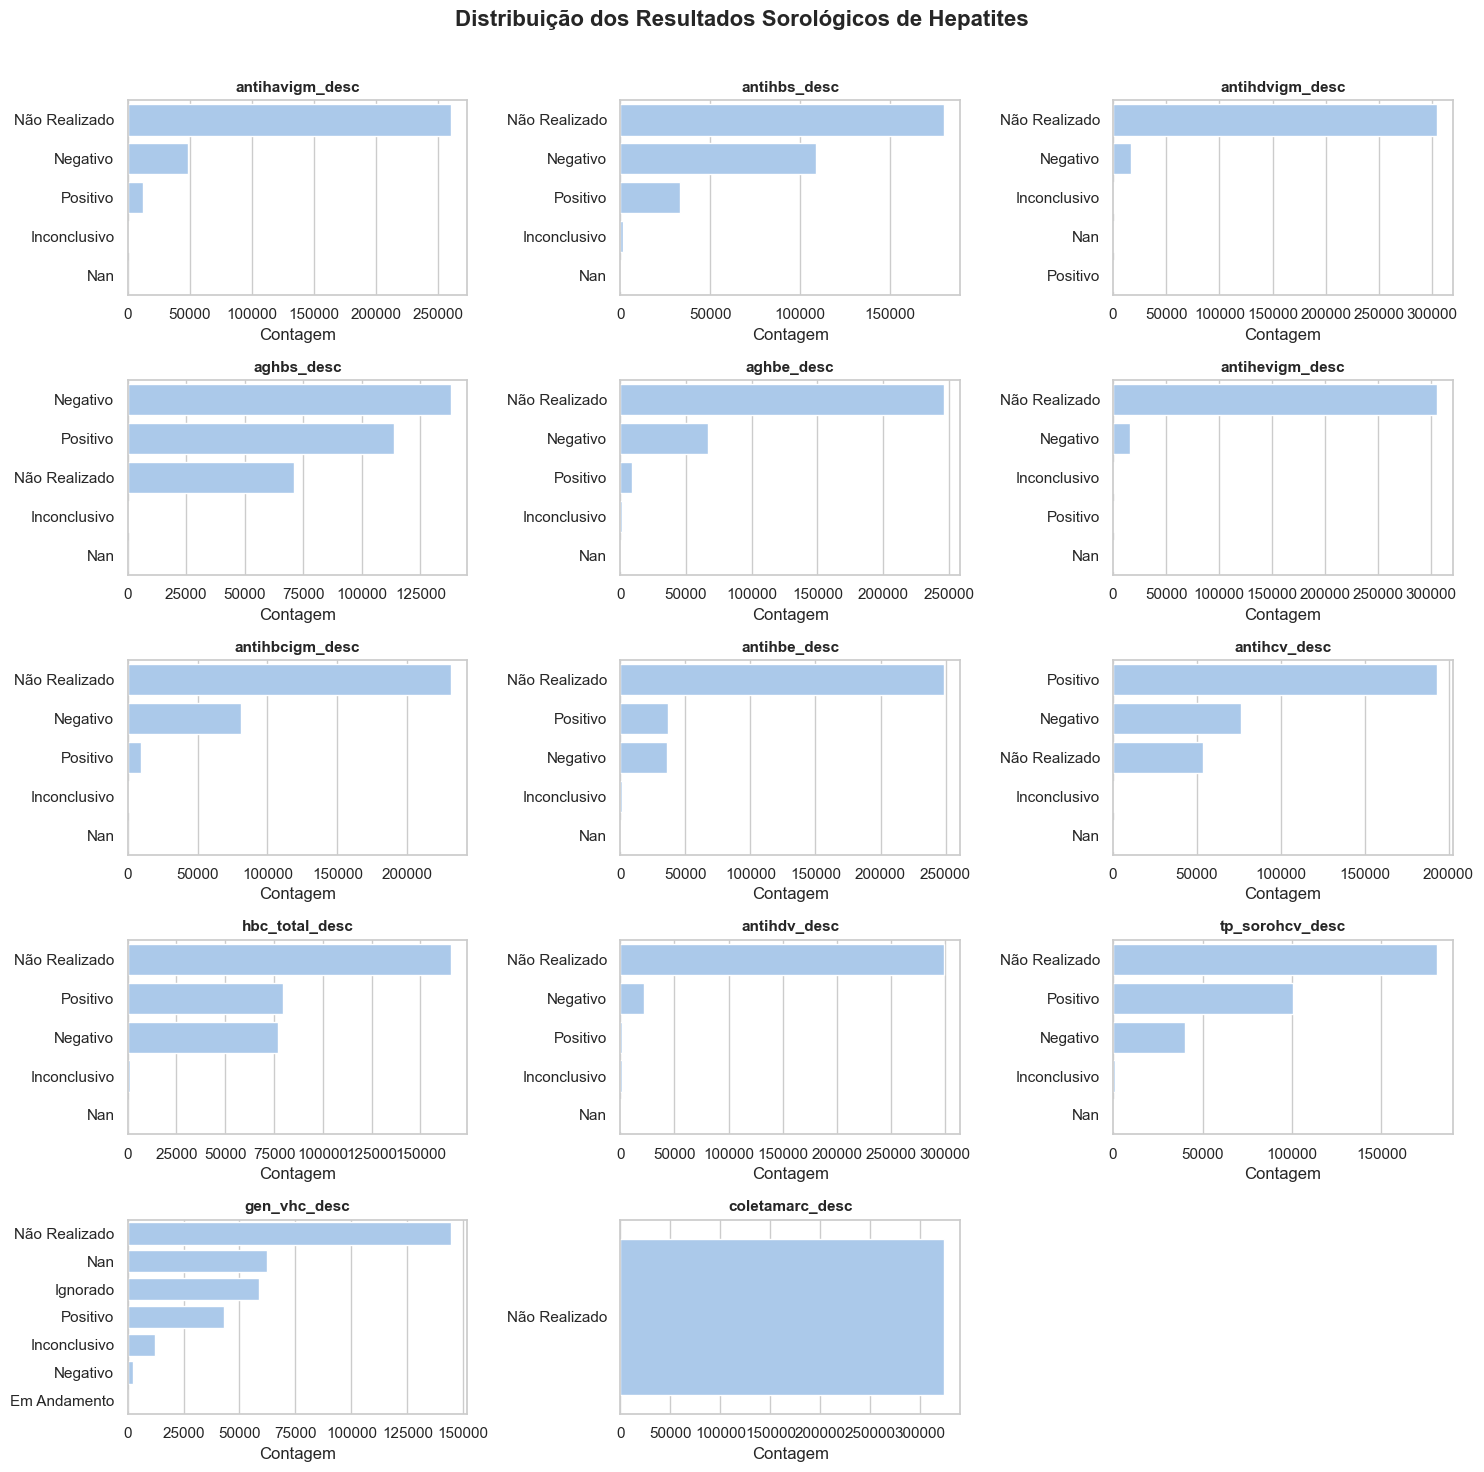

In [43]:
# Lista de colunas laboratoriais
cols_lab = [
    'antihavigm_desc', 'antihbs_desc', 'antihdvigm_desc', 'aghbs_desc',
    'aghbe_desc', 'antihevigm_desc', 'antihbcigm_desc', 'antihbe_desc',
    'antihcv_desc', 'hbc_total_desc', 'antihdv_desc', 'tp_sorohcv_desc',
    'gen_vhc_desc', 'coletamarc_desc'
]

# Filtrar apenas as colunas existentes
cols_lab = [c for c in cols_lab if c in df.columns]

# Padronizar texto (maiusculas/minusculas)
for c in cols_lab:
    df[c] = df[c].astype(str).str.strip().str.title()

# Configurações visuais
sns.set(style="whitegrid", palette="pastel")

# Criar grid de subplots dinâmico
n = len(cols_lab)
n_cols = 3
n_rows = (n // n_cols) + (1 if n % n_cols else 0)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))

# Garantir que axes é iterável (em caso de 1 linha)
axes = axes.flatten()

# Loop pelos marcadores
for i, col in enumerate(cols_lab):
    ax = axes[i]
    order = df[col].value_counts().index
    sns.countplot(y=col, data=df, order=order, ax=ax)
    ax.set_title(f'{col}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Contagem')
    ax.set_ylabel('')

# Remover subplots vazios
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribuição dos Resultados Sorológicos de Hepatites', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


#### Análise com a coluna **'FORMA_VALIDA'**

C:\Users\diego\AppData\Local\Temp\ipykernel_45724\1581089241.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_EDA, x="forma_valida", palette="viridis")


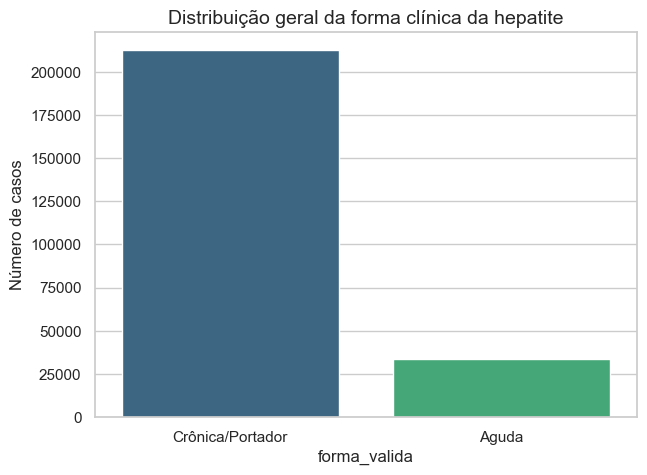

In [50]:
plt.figure(figsize=(7,5))
sns.countplot(data=df_EDA, x="forma_valida", palette="viridis")
plt.title("Distribuição geral da forma clínica da hepatite", fontsize=14)
plt.ylabel("Número de casos")
plt.show()

In [66]:
df_EDA['cs_sexo'].fillna('Ignorado',inplace=True)

C:\Users\diego\AppData\Local\Temp\ipykernel_45724\4220783883.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_EDA['cs_sexo'].fillna('Ignorado',inplace=True)


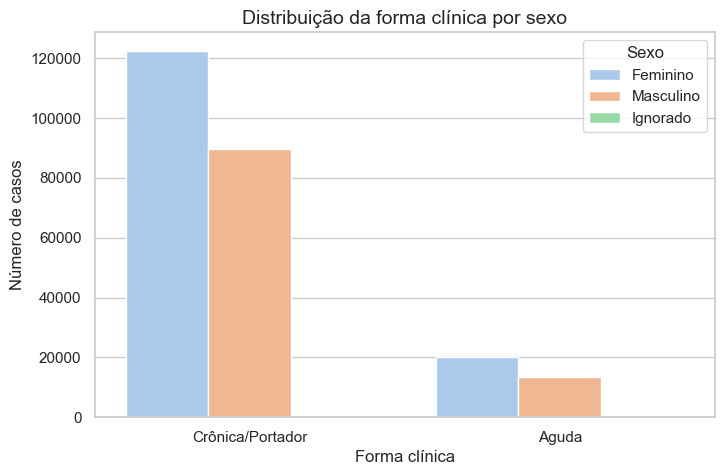

In [68]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_EDA, x="forma_valida", hue="cs_sexo", palette="pastel")
plt.title("Distribuição da forma clínica por sexo", fontsize=14)
plt.xlabel("Forma clínica")
plt.ylabel("Número de casos")
plt.legend(title="Sexo", labels=["Feminino","Masculino","Ignorado"])
plt.show()


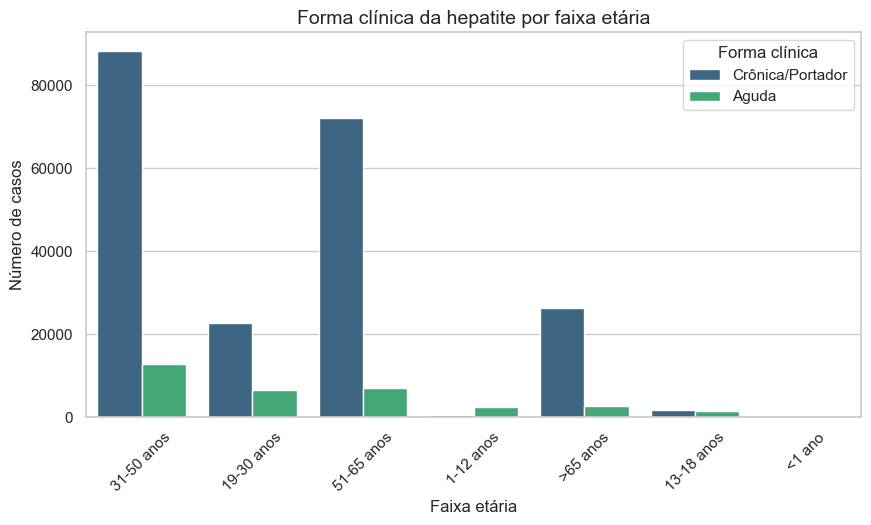

In [80]:
plt.figure(figsize=(10,5))
sns.countplot(data=df_EDA, x="faixa_etaria", hue="forma_valida", palette="viridis")
plt.title("Forma clínica da hepatite por faixa etária", fontsize=14)
plt.xlabel("Faixa etária")
plt.ylabel("Número de casos")
plt.legend(title="Forma clínica")
plt.xticks(rotation=45)
plt.show()

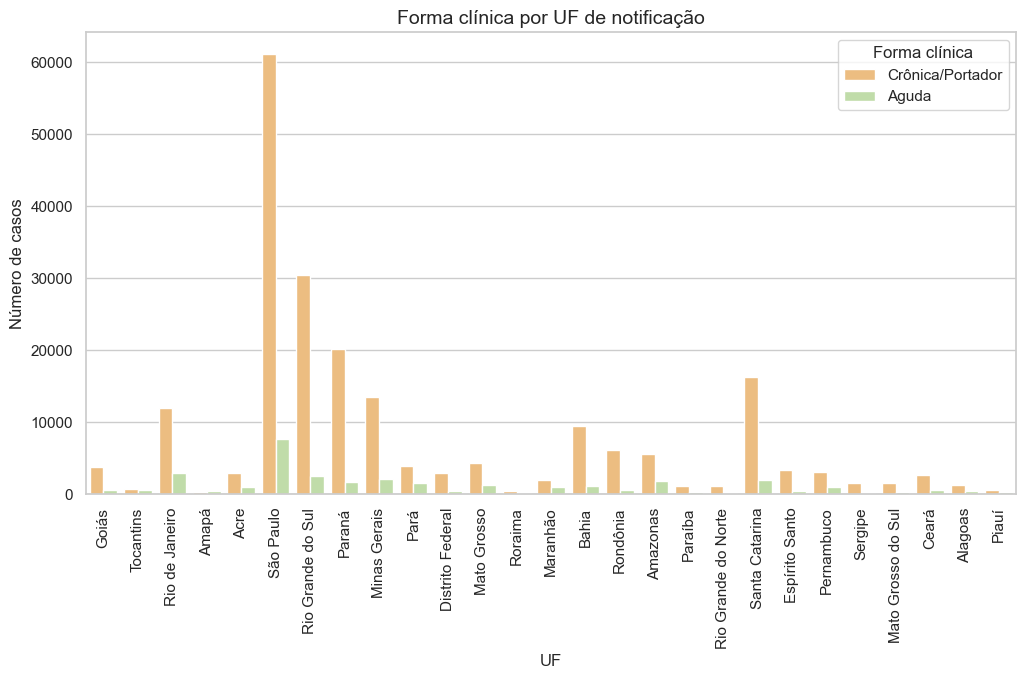

In [82]:
plt.figure(figsize=(12,6))
sns.countplot(data=df_EDA, x="sg_uf_not", hue="forma_valida", palette="Spectral")
plt.title("Forma clínica por UF de notificação", fontsize=14)
plt.xlabel("UF")
plt.ylabel("Número de casos")
plt.legend(title="Forma clínica")
plt.xticks(rotation=90)
plt.show()

C:\Users\diego\AppData\Local\Temp\ipykernel_45724\2209975124.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_EDA, x="forma_valida", y="idhm", palette="coolwarm")


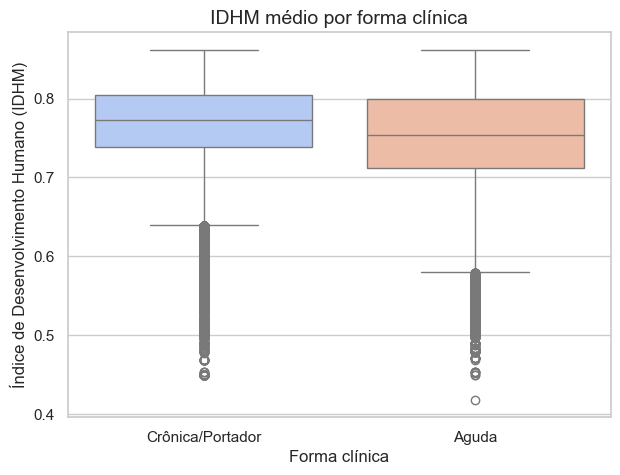

In [86]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df_EDA, x="forma_valida", y="idhm", palette="coolwarm")
plt.title("IDHM médio por forma clínica", fontsize=14)
plt.xlabel("Forma clínica")
plt.ylabel("Índice de Desenvolvimento Humano (IDHM)")
plt.show()

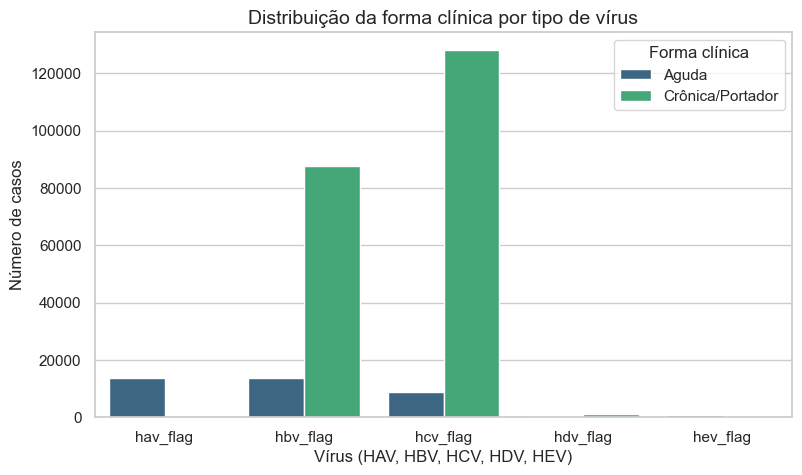

In [88]:
# Filtrar apenas as flags dos vírus
virus_cols = ["hav_flag", "hbv_flag", "hcv_flag", "hdv_flag", "hev_flag"]

# Converter flags (0/1) para formato longo
df_virus = df_EDA.melt(id_vars=["forma_valida"], value_vars=virus_cols,
                   var_name="virus", value_name="flag")

# Filtrar apenas casos positivos
df_virus = df_virus[df_virus["flag"] == 1]

plt.figure(figsize=(9,5))
sns.countplot(data=df_virus, x="virus", hue="forma_valida", palette="viridis")
plt.title("Distribuição da forma clínica por tipo de vírus", fontsize=14)
plt.xlabel("Vírus (HAV, HBV, HCV, HDV, HEV)")
plt.ylabel("Número de casos")
plt.legend(title="Forma clínica")
plt.show()


C:\Users\diego\AppData\Local\Temp\ipykernel_45724\1750473496.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_EDA, x="forma_valida", y="taxa_agua_encanada", palette="crest", ax=axes[0])
C:\Users\diego\AppData\Local\Temp\ipykernel_45724\1750473496.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_EDA, x="forma_valida", y="prop_pobreza_extrema", palette="rocket", ax=axes[1])


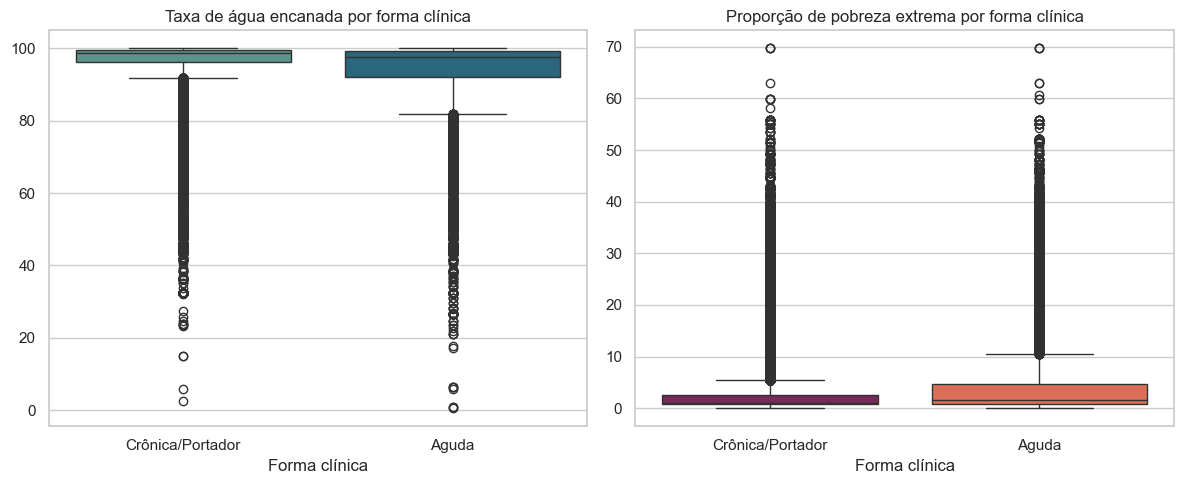

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.boxplot(data=df_EDA, x="forma_valida", y="taxa_agua_encanada", palette="crest", ax=axes[0])
axes[0].set_title("Taxa de água encanada por forma clínica")

sns.boxplot(data=df_EDA, x="forma_valida", y="prop_pobreza_extrema", palette="rocket", ax=axes[1])
axes[1].set_title("Proporção de pobreza extrema por forma clínica")

for ax in axes:
    ax.set_xlabel("Forma clínica")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()


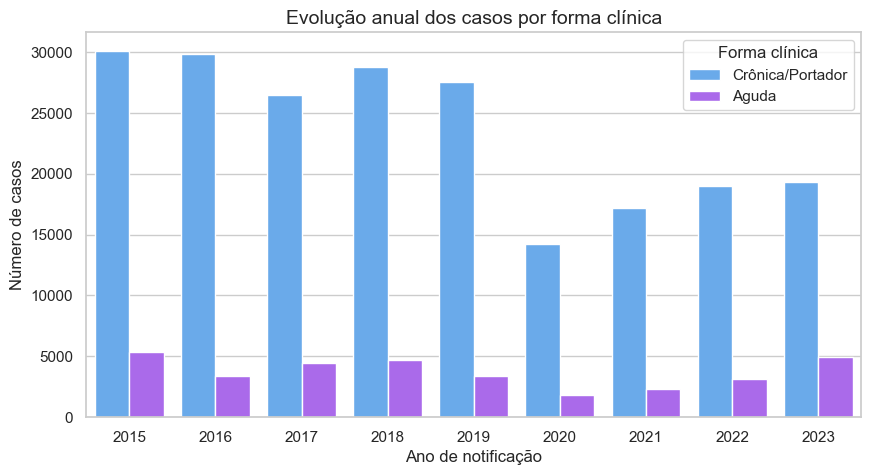

In [94]:
plt.figure(figsize=(10,5))
sns.countplot(data=df_EDA, x="ano_notific", hue="forma_valida", palette="cool")
plt.title("Evolução anual dos casos por forma clínica", fontsize=14)
plt.xlabel("Ano de notificação")
plt.ylabel("Número de casos")
plt.legend(title="Forma clínica")
plt.show()
